In [1]:
import os.path as op
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
short_color=np.array([255,0,0])/255.0
long_color=np.array([0,0,255])/255.0

td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

ipsi_color=np.array([90,180,172])/255.0
contra_color=np.array([216,179,101])/255.0

# TF

In [5]:
all_tf={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
tf_time=None
tf_freqs=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']

In [6]:
t_stim_idx=np.where((tf_time>=-1.5) & (tf_time<=.5))[0]
t_resp_idx=np.where((tf_time>=-.5) & (tf_time<=1.5))[0]
tf_stim_time=tf_time[t_stim_idx]
tf_resp_time=tf_time[t_resp_idx]
base_idx=np.where((tf_time>=-1.5) & (tf_time<=-1))[0]

f_idx=(tf_freqs>5) & (tf_freqs<100)
tf_freqs=tf_freqs[f_idx]

tf_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            for condition in ['SHORT','LONG']:
                base_tf=np.mean(all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,base_idx],axis=-1)
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)
        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            for condition in ['SHORT','LONG']:
                base_tf=np.mean(all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,base_idx],axis=-1)
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)            
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                tf_bc[group][epoch][condition][hemi]=np.array(tf_bc[group][epoch][condition][hemi])
                
n_td=tf_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=tf_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


# Contralateral: TD-ASD

stat_fun(H1): min=-0.000004 max=7.746554
Running initial clustering …
Using 155 thresholds from 0.00 to 7.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.993
stat_fun(H1): min=-0.000006 max=7.355013
Running initial clustering …
Using 148 thresholds from 0.00 to 7.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.978
stat_fun(H1): min=-0.000004 max=10.279757
Running initial clustering …
Using 206 thresholds from 0.00 to 10.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000003 max=5.133784
Running initial clustering …
Using 103 thresholds from 0.00 to 5.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.999


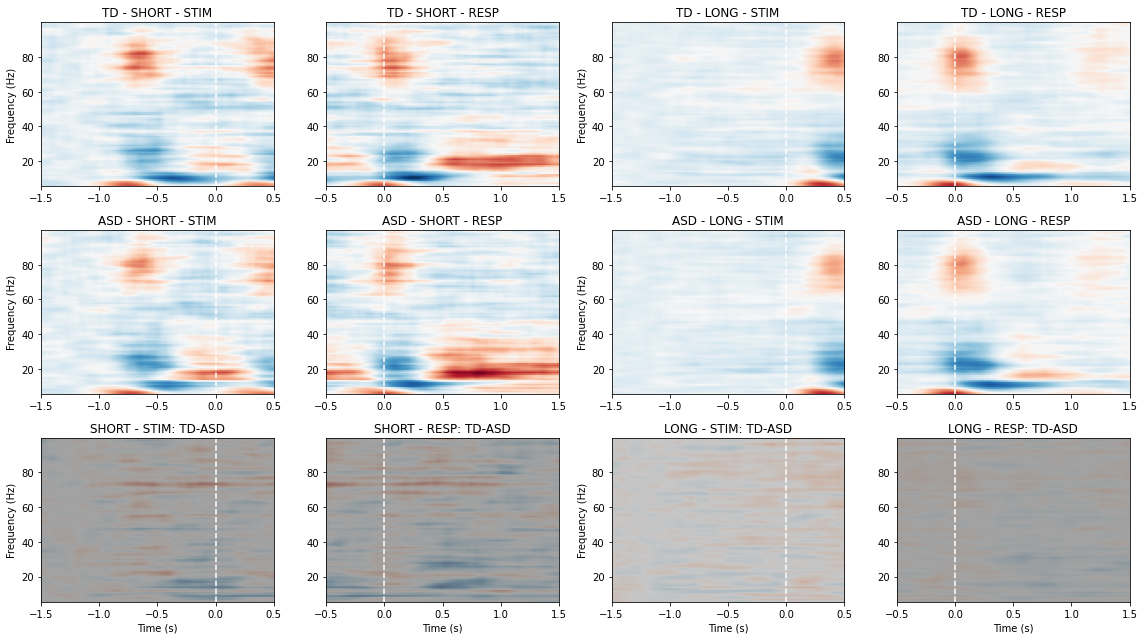

In [7]:
threshold_tfce = dict(start=0, step=0.05)

plt.figure(figsize=(16,9))
td_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['contra'],axis=0)
td_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['contra'],axis=0)
asd_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['contra'],axis=0)
asd_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['contra'],axis=0)

td_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['contra'],axis=0)
td_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['contra'],axis=0)
asd_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['contra'],axis=0)
asd_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['contra'],axis=0)

min_val=np.min(np.vstack([td_stim_short[:], td_resp_short[:], asd_stim_short[:], asd_resp_short[:], td_stim_long[:], td_resp_long[:], asd_stim_long[:], asd_resp_long[:]]))
max_val=np.max(np.vstack([td_stim_short[:], td_resp_short[:], asd_stim_short[:], asd_resp_short[:], td_stim_long[:], td_resp_long[:], asd_stim_long[:], asd_resp_long[:]]))

ax=plt.subplot(3,4,1)
ax.imshow(
    td_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('TD - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    td_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('TD - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    td_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('TD - LONG - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    td_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('TD - LONG - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    asd_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('ASD - SHORT - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    asd_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('ASD - SHORT - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    asd_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('ASD - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    asd_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('ASD - LONG - RESP')

stim_short_diff=td_stim_short-asd_stim_short
resp_short_diff=td_resp_short-asd_resp_short
stim_long_diff=td_stim_long-asd_stim_long
resp_long_diff=td_resp_long-asd_resp_long

all_diff=np.vstack([stim_short_diff[:], resp_short_diff[:], stim_long_diff[:], resp_long_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [
    tf_bc['ASD']['STIM']['SHORT']['contra'],
    tf_bc['TD']['STIM']['SHORT']['contra']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    stim_short_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)
print(np.min(cluster_p_values))


# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - STIM: TD-ASD')

ax=plt.subplot(3,4,10)

data = [
    tf_bc['ASD']['RESP']['SHORT']['contra'],
    tf_bc['TD']['RESP']['SHORT']['contra']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    resp_short_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)
print(np.min(cluster_p_values))

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - RESP: TD-ASD')

ax=plt.subplot(3,4,11)

data = [
    tf_bc['ASD']['STIM']['LONG']['contra'], 
    tf_bc['TD']['STIM']['LONG']['contra']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    stim_long_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - STIM: TD-ASD')

ax=plt.subplot(3,4,12)

data = [
    tf_bc['ASD']['RESP']['LONG']['contra'], 
    tf_bc['TD']['RESP']['LONG']['contra']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    resp_long_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_long_diff.shape)

print(np.min(cluster_p_values))
for clu, p_val in zip(clusters, cluster_p_values):
    p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - RESP: TD-ASD')

plt.tight_layout()

# Ipsilateral: TD-ASD

stat_fun(H1): min=-0.000003 max=9.625538
Running initial clustering …
Using 97 thresholds from 0.00 to 9.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.833
stat_fun(H1): min=-0.000002 max=8.655056
Running initial clustering …
Using 87 thresholds from 0.00 to 8.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.696
stat_fun(H1): min=-0.000002 max=9.834208
Running initial clustering …
Using 99 thresholds from 0.00 to 9.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000006 max=6.508799
Running initial clustering …
Using 66 thresholds from 0.00 to 6.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

0.734


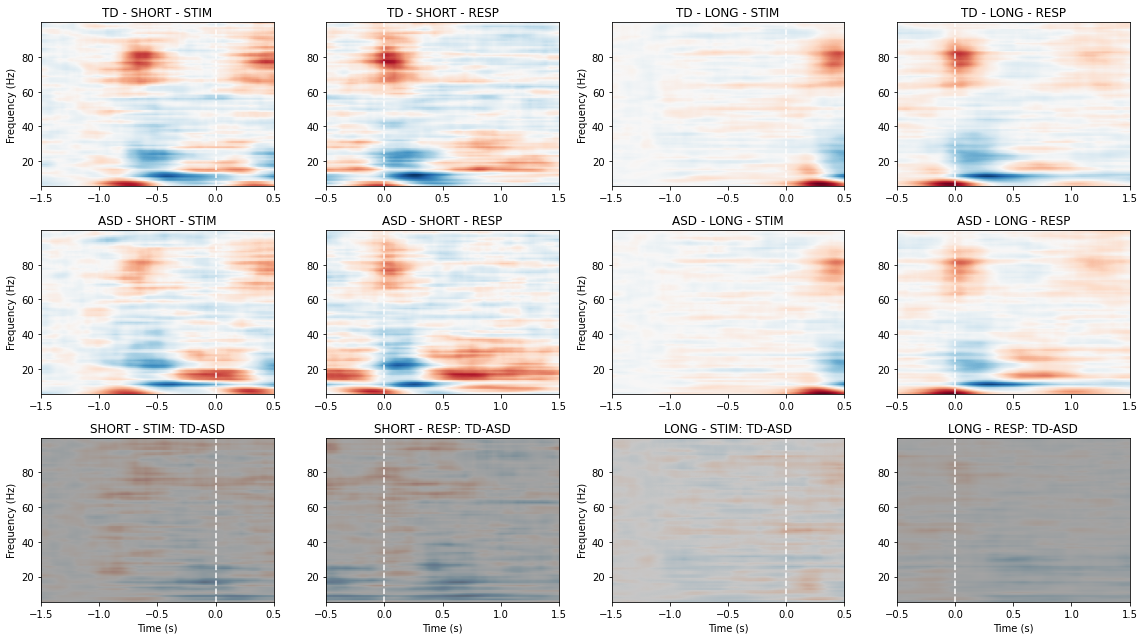

In [8]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(16,9))
td_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['ipsi'],axis=0)
td_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['ipsi'],axis=0)
asd_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['ipsi'],axis=0)
asd_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['ipsi'],axis=0)

td_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['ipsi'],axis=0)
td_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['ipsi'],axis=0)
asd_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['ipsi'],axis=0)
asd_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['ipsi'],axis=0)

min_val=np.min(np.vstack([td_stim_short[:], td_resp_short[:], asd_stim_short[:], asd_resp_short[:], td_stim_long[:], td_resp_long[:], asd_stim_long[:], asd_resp_long[:]]))
max_val=np.max(np.vstack([td_stim_short[:], td_resp_short[:], asd_stim_short[:], asd_resp_short[:], td_stim_long[:], td_resp_long[:], asd_stim_long[:], asd_resp_long[:]]))

ax=plt.subplot(3,4,1)
ax.imshow(
    td_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('TD - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    td_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('TD - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    td_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('TD - LONG - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    td_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('TD - LONG - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    asd_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('ASD - SHORT - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    asd_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('ASD - SHORT - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    asd_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('ASD - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    asd_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('ASD - LONG - RESP')

stim_short_diff=td_stim_short-asd_stim_short
resp_short_diff=td_resp_short-asd_resp_short
stim_long_diff=td_stim_long-asd_stim_long
resp_long_diff=td_resp_long-asd_resp_long

all_diff=np.vstack([stim_short_diff[:], resp_short_diff[:], stim_long_diff[:], resp_long_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [
    tf_bc['ASD']['STIM']['SHORT']['ipsi'], 
    tf_bc['TD']['STIM']['SHORT']['ipsi']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    stim_short_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)
print(np.min(cluster_p_values))


# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - STIM: TD-ASD')

ax=plt.subplot(3,4,10)

data = [
    tf_bc['ASD']['RESP']['SHORT']['ipsi'],
    tf_bc['TD']['RESP']['SHORT']['ipsi']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    resp_short_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)
print(np.min(cluster_p_values))

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - RESP: TD-ASD')

ax=plt.subplot(3,4,11)

data = [
    tf_bc['ASD']['STIM']['LONG']['ipsi'], 
    tf_bc['TD']['STIM']['LONG']['ipsi']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    stim_long_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - STIM: TD-ASD')

ax=plt.subplot(3,4,12)

data = [
    tf_bc['ASD']['RESP']['LONG']['ipsi'], 
    tf_bc['TD']['RESP']['LONG']['ipsi']
]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    resp_long_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_long_diff.shape)

print(np.min(cluster_p_values))
for clu, p_val in zip(clusters, cluster_p_values):
    p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.7
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - RESP: TD-ASD')

plt.tight_layout()

# TD: SHORT-LONG

stat_fun(H1): min=-0.000002 max=41.890293
Running initial clustering …
Using 419 thresholds from 0.00 to 41.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000004 max=30.742393
Running initial clustering …
Using 308 thresholds from 0.00 to 30.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000000 max=36.446026
Running initial clustering …
Using 365 thresholds from 0.00 to 36.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000005 max=33.017582
Running initial clustering …
Using 331 thresholds from 0.00 to 33.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

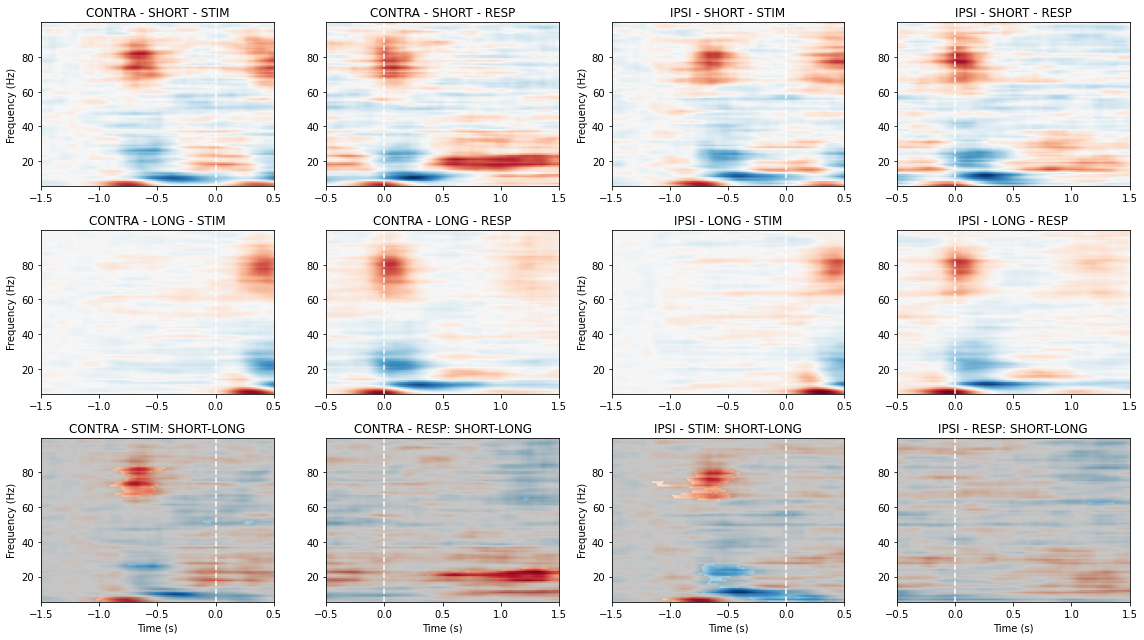

In [9]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(16,9))
contra_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['contra'],axis=0)
ipsi_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['ipsi'],axis=0)
ipsi_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['ipsi'],axis=0)

contra_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['contra'],axis=0)
ipsi_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['ipsi'],axis=0)
ipsi_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['ipsi'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))

ax=plt.subplot(3,4,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    ipsi_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - SHORT - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    ipsi_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - SHORT - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    ipsi_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    ipsi_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - LONG - RESP')

contra_stim_diff=contra_stim_short-contra_stim_long
contra_resp_diff=contra_resp_short-contra_resp_long
ipsi_stim_diff=ipsi_stim_short-ipsi_stim_long
ipsi_resp_diff=ipsi_resp_short-ipsi_resp_long

all_diff=np.vstack([contra_stim_diff[:], contra_resp_diff[:], ipsi_stim_diff[:], ipsi_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [tf_bc['TD']['STIM']['SHORT']['contra'], tf_bc['TD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as contra_stim_diff)
p_map = np.ones(contra_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - STIM: SHORT-LONG')

ax=plt.subplot(3,4,10)

data = [tf_bc['TD']['RESP']['SHORT']['contra'], tf_bc['TD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as contra_resp_diff)
p_map = np.ones(contra_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - RESP: SHORT-LONG')

ax=plt.subplot(3,4,11)

data = [tf_bc['TD']['STIM']['SHORT']['ipsi'], tf_bc['TD']['STIM']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    ipsi_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as ipsi_stim_diff)
p_map = np.ones(ipsi_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('IPSI - STIM: SHORT-LONG')

ax=plt.subplot(3,4,12)

data = [tf_bc['TD']['RESP']['SHORT']['ipsi'], tf_bc['TD']['RESP']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    ipsi_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as ipsi_resp_diff)
p_map = np.ones(ipsi_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('IPSI - RESP: SHORT-LONG')

plt.tight_layout()

# ASD: SHORT-LONG

stat_fun(H1): min=-0.000003 max=52.031670
Running initial clustering …
Using 521 thresholds from 0.00 to 52.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000007 max=36.835320
Running initial clustering …
Using 369 thresholds from 0.00 to 36.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000000 max=33.356621
Running initial clustering …
Using 334 thresholds from 0.00 to 33.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000009 max=22.862215
Running initial clustering …
Using 229 thresholds from 0.00 to 22.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

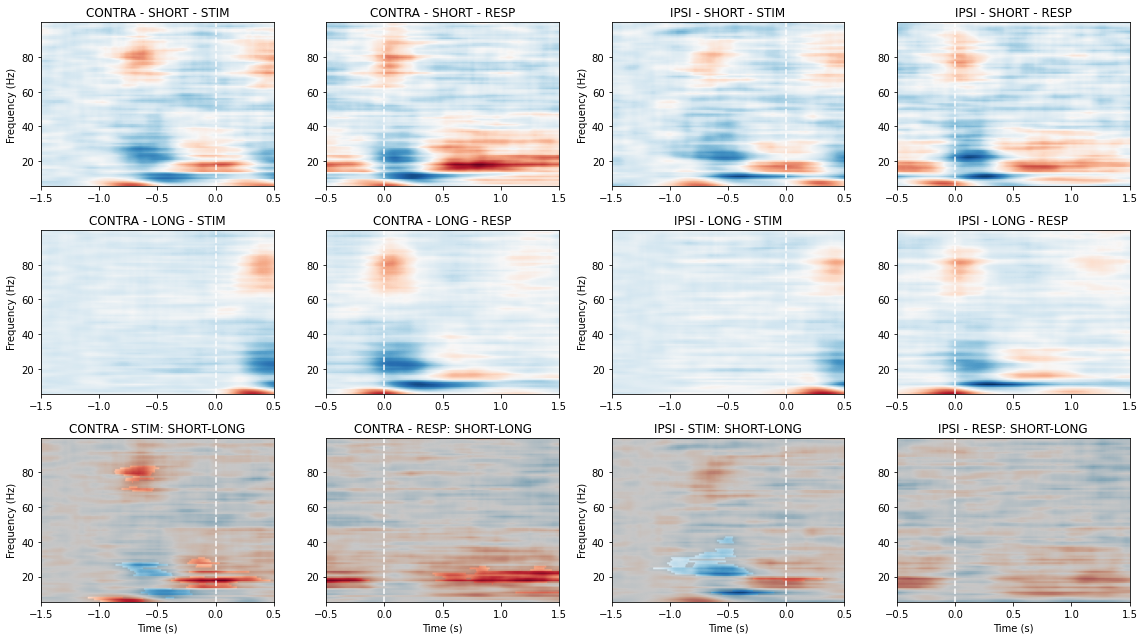

In [10]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(16,9))
contra_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['contra'],axis=0)
ipsi_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['ipsi'],axis=0)
ipsi_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['ipsi'],axis=0)

contra_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['contra'],axis=0)
ipsi_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['ipsi'],axis=0)
ipsi_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['ipsi'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))

ax=plt.subplot(3,4,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    ipsi_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - SHORT - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    ipsi_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - SHORT - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    ipsi_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    ipsi_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - LONG - RESP')

contra_stim_diff=contra_stim_short-contra_stim_long
contra_resp_diff=contra_resp_short-contra_resp_long
ipsi_stim_diff=ipsi_stim_short-ipsi_stim_long
ipsi_resp_diff=ipsi_resp_short-ipsi_resp_long

all_diff=np.vstack([contra_stim_diff[:], contra_resp_diff[:], ipsi_stim_diff[:], ipsi_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [tf_bc['ASD']['STIM']['SHORT']['contra'], tf_bc['ASD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as contra_stim_diff)
p_map = np.ones(contra_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - STIM: SHORT-LONG')

ax=plt.subplot(3,4,10)

data = [tf_bc['ASD']['RESP']['SHORT']['contra'], tf_bc['ASD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as contra_resp_diff)
p_map = np.ones(contra_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - RESP: SHORT-LONG')

ax=plt.subplot(3,4,11)

data = [tf_bc['ASD']['STIM']['SHORT']['ipsi'], tf_bc['ASD']['STIM']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    ipsi_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as ipsi_stim_diff)
p_map = np.ones(ipsi_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('IPSI - STIM: SHORT-LONG')

ax=plt.subplot(3,4,12)

data = [tf_bc['ASD']['RESP']['SHORT']['ipsi'], tf_bc['ASD']['RESP']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    ipsi_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as ipsi_resp_diff)
p_map = np.ones(ipsi_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('IPSI - RESP: SHORT-LONG')

plt.tight_layout()

# TD: CONTRA-IPSI

stat_fun(H1): min=-0.000003 max=13.867408
Running initial clustering …
Using 139 thresholds from 0.00 to 13.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000006 max=18.883562
Running initial clustering …
Using 189 thresholds from 0.00 to 18.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000005 max=15.722621
Running initial clustering …
Using 158 thresholds from 0.00 to 15.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000007 max=9.529502
Running initial clustering …
Using 96 thresholds from 0.00 to 9.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

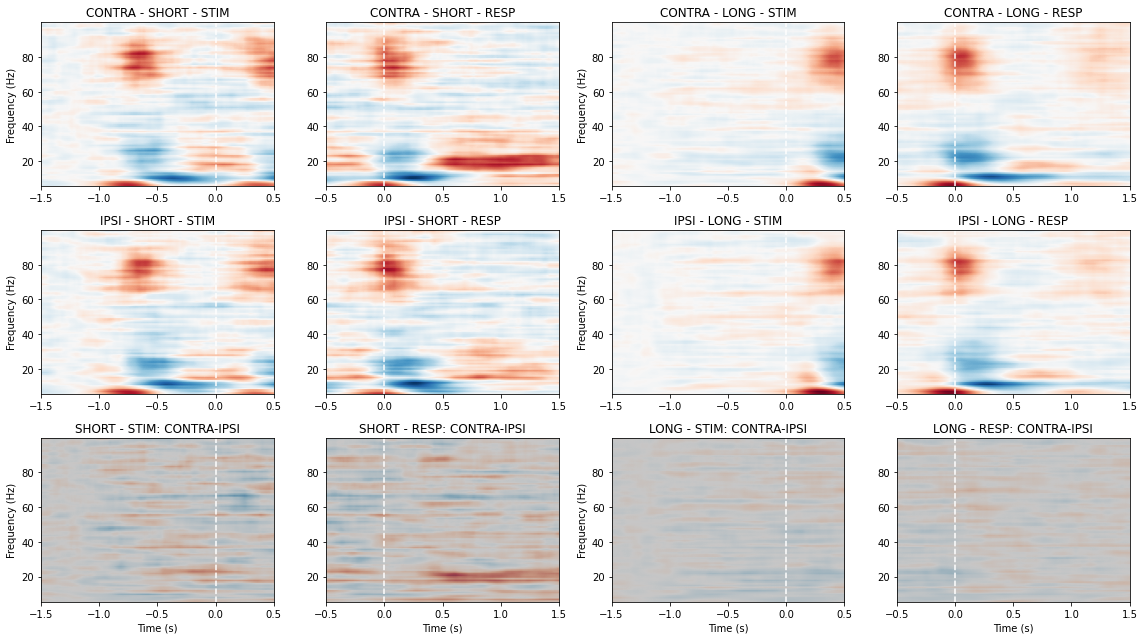

In [11]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(16,9))
contra_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['contra'],axis=0)
ipsi_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['ipsi'],axis=0)
ipsi_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['ipsi'],axis=0)

contra_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['contra'],axis=0)
ipsi_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['ipsi'],axis=0)
ipsi_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['ipsi'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))

ax=plt.subplot(3,4,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    ipsi_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - SHORT - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    ipsi_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - SHORT - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    ipsi_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    ipsi_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - LONG - RESP')

short_stim_diff=contra_stim_short-ipsi_stim_short
short_resp_diff=contra_resp_short-ipsi_resp_short
long_stim_diff=contra_stim_long-ipsi_stim_long
long_resp_diff=contra_resp_long-ipsi_resp_long

all_diff=np.vstack([short_stim_diff[:], short_resp_diff[:], ipsi_stim_diff[:], ipsi_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [tf_bc['TD']['STIM']['SHORT']['contra'], tf_bc['TD']['STIM']['SHORT']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    short_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - STIM: CONTRA-IPSI')

ax=plt.subplot(3,4,10)

data = [tf_bc['TD']['RESP']['SHORT']['contra'], tf_bc['TD']['RESP']['SHORT']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    short_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - RESP: CONTRA-IPSI')

ax=plt.subplot(3,4,11)

data = [tf_bc['TD']['STIM']['LONG']['contra'], tf_bc['TD']['STIM']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    long_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - STIM: CONTRA-IPSI')

ax=plt.subplot(3,4,12)

data = [tf_bc['TD']['RESP']['LONG']['contra'], tf_bc['TD']['RESP']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    long_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - RESP: CONTRA-IPSI')

plt.tight_layout()

# ASD: CONTRA-IPSI

stat_fun(H1): min=-0.000007 max=11.474834
Running initial clustering …
Using 115 thresholds from 0.00 to 11.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000003 max=9.600633
Running initial clustering …
Using 97 thresholds from 0.00 to 9.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000002 max=9.441594
Running initial clustering …
Using 95 thresholds from 0.00 to 9.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

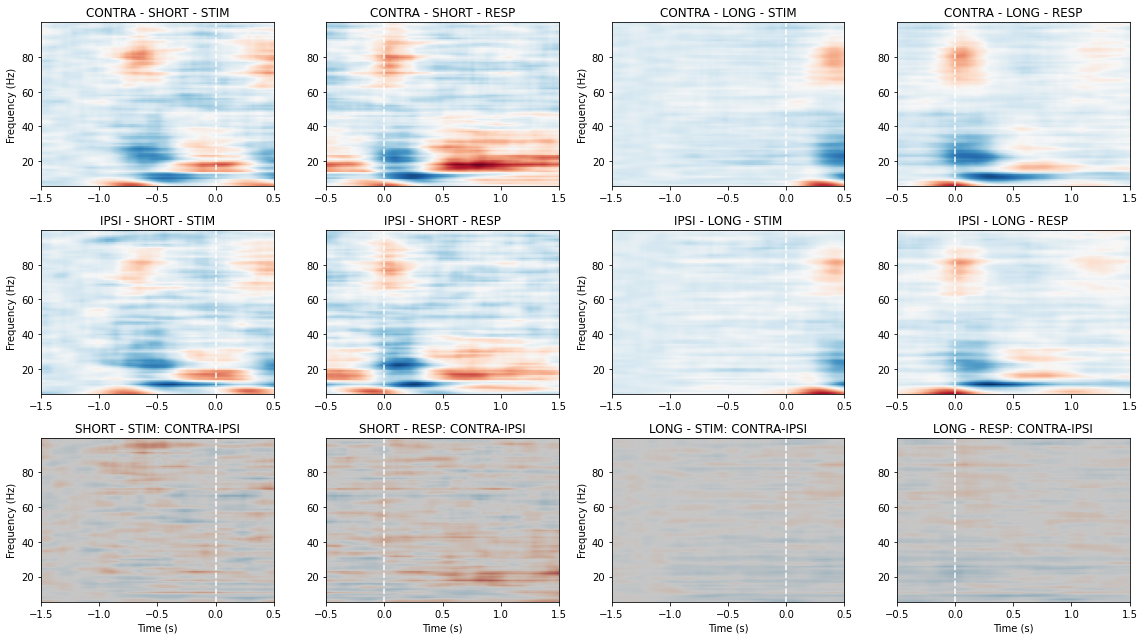

In [12]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(16,9))
contra_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['contra'],axis=0)
ipsi_stim_short=np.mean(tf_bc['ASD']['STIM']['SHORT']['ipsi'],axis=0)
ipsi_resp_short=np.mean(tf_bc['ASD']['RESP']['SHORT']['ipsi'],axis=0)

contra_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['contra'],axis=0)
ipsi_stim_long=np.mean(tf_bc['ASD']['STIM']['LONG']['ipsi'],axis=0)
ipsi_resp_long=np.mean(tf_bc['ASD']['RESP']['LONG']['ipsi'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    ipsi_stim_short[:], 
    ipsi_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
    ipsi_stim_long[:], 
    ipsi_resp_long[:]
]))

ax=plt.subplot(3,4,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,4,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,4,3)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,4,4)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

ax=plt.subplot(3,4,5)
ax.imshow(
    ipsi_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - SHORT - STIM')

ax=plt.subplot(3,4,6)
ax.imshow(
    ipsi_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - SHORT - RESP')

ax=plt.subplot(3,4,7)
ax.imshow(
    ipsi_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('IPSI - LONG - STIM')

ax=plt.subplot(3,4,8)
ax.imshow(
    ipsi_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('IPSI - LONG - RESP')

short_stim_diff=contra_stim_short-ipsi_stim_short
short_resp_diff=contra_resp_short-ipsi_resp_short
long_stim_diff=contra_stim_long-ipsi_stim_long
long_resp_diff=contra_resp_long-ipsi_resp_long

all_diff=np.vstack([short_stim_diff[:], short_resp_diff[:], ipsi_stim_diff[:], ipsi_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,4,9)

data = [tf_bc['ASD']['STIM']['SHORT']['contra'], tf_bc['ASD']['STIM']['SHORT']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    short_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - STIM: CONTRA-IPSI')

ax=plt.subplot(3,4,10)

data = [tf_bc['ASD']['RESP']['SHORT']['contra'], tf_bc['ASD']['RESP']['SHORT']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    short_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_short_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('SHORT - RESP: CONTRA-IPSI')

ax=plt.subplot(3,4,11)

data = [tf_bc['ASD']['STIM']['LONG']['contra'], tf_bc['ASD']['STIM']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    long_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(stim_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - STIM: CONTRA-IPSI')

ax=plt.subplot(3,4,12)

data = [tf_bc['ASD']['RESP']['LONG']['contra'], tf_bc['ASD']['RESP']['LONG']['ipsi']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    long_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(resp_long_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('LONG - RESP: CONTRA-IPSI')

plt.tight_layout()

# Beta power

In [13]:
all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

In [14]:
t_stim_idx=np.where((power_time>=-1.5) & (power_time<=0.5))[0]
t_resp_idx=np.where((power_time>=-.5) & (power_time<=1.5))[0]
base_idx=np.where((power_time>=-1.5) & (power_time<=-1))[0]
        
beta_pow_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

s_idx=0

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            for condition in ['SHORT','LONG']:
                base_pow=np.mean(all_beta_power[hemi]['STIM'][condition][s_idx][base_idx])
                b_pow_stim=all_beta_power[hemi]['STIM'][condition][s_idx][t_stim_idx]
                b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                b_pow_resp=all_beta_power[hemi]['RESP'][condition][s_idx][t_resp_idx]
                b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
        s_idx+=1
        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            for condition in ['SHORT','LONG']:
                base_pow=np.mean(all_beta_power[hemi]['STIM'][condition][s_idx][base_idx])
                b_pow_stim=all_beta_power[hemi]['STIM'][condition][s_idx][t_stim_idx]
                b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                b_pow_resp=all_beta_power[hemi]['RESP'][condition][s_idx][t_resp_idx]
                b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
        s_idx+=1
        
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                beta_pow_bc[group][epoch][condition][hemi]=np.array(beta_pow_bc[group][epoch][condition][hemi])
                
n_td=beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=beta_pow_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


stat_fun(H1): min=0.000001 max=2.176867
Running initial clustering …
Using 218 thresholds from 0.00 to 2.17 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

[1. 1. 1. ... 1. 1. 1.]
stat_fun(H1): min=0.000046 max=2.428287
Running initial clustering …
Using 243 thresholds from 0.00 to 2.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

[0.671 0.671 0.671 ... 0.917 0.918 0.918]
stat_fun(H1): min=-0.000001 max=3.266106
Running initial clustering …
Using 327 thresholds from 0.00 to 3.26 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

[0.51  0.504 0.5   ... 0.928 0.928 0.928]
stat_fun(H1): min=0.000000 max=6.788678
Running initial clustering …
Using 679 thresholds from 0.00 to 6.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

[1. 1. 1. ... 1. 1. 1.]
stat_fun(H1): min=0.000016 max=3.991900
Running initial clustering …
Using 400 thresholds from 0.00 to 3.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

[0.998 0.998 0.998 ... 0.304 0.302 0.3  ]


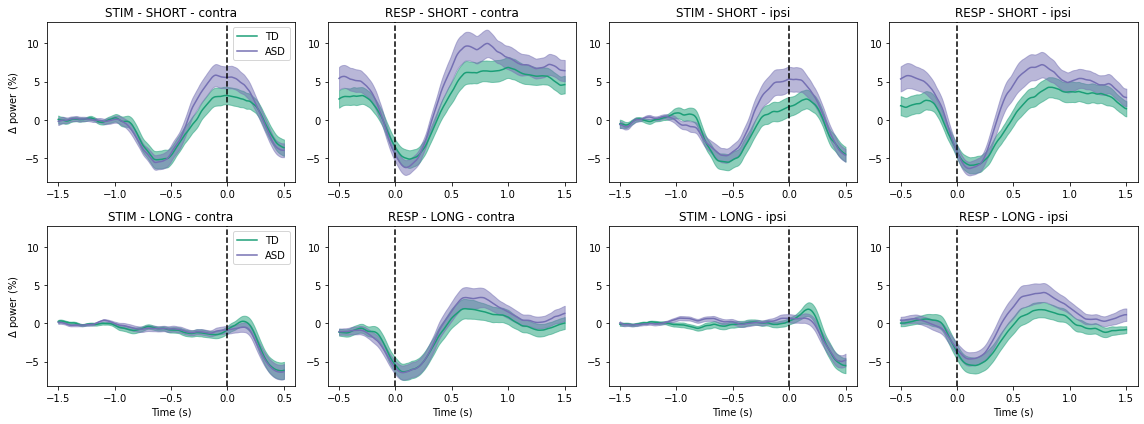

In [22]:
plt.figure(figsize=(16,6))

# Define condition combinations and axes
conditions = [
    ('STIM', 'SHORT', 'contra', plt.subplot(2,4,1), 'STIM - SHORT - contra'),
    ('RESP', 'SHORT', 'contra', plt.subplot(2,4,2), 'RESP - SHORT - contra'),
    ('STIM', 'LONG',  'contra', plt.subplot(2,4,5), 'STIM - LONG - contra'),
    ('RESP', 'LONG',  'contra', plt.subplot(2,4,6), 'RESP - LONG - contra'),
    ('STIM', 'SHORT', 'ipsi',  plt.subplot(2,4,3), 'STIM - SHORT - ipsi'),
    ('RESP', 'SHORT', 'ipsi',  plt.subplot(2,4,4), 'RESP - SHORT - ipsi'),
    ('STIM', 'LONG',  'ipsi',  plt.subplot(2,4,7), 'STIM - LONG - ipsi'),
    ('RESP', 'LONG',  'ipsi',  plt.subplot(2,4,8), 'RESP - LONG - ipsi')
]

threshold_tfce = dict(start=0, step=0.01)
all_axes = []

for evt, dur, hemi, ax, title in conditions:
    time_bins=[]
    if evt=='STIM':
        time_bins=power_time[t_stim_idx]
    else:
        time_bins=power_time[t_resp_idx]
    # TD
    m_pow = np.mean(beta_pow_bc['TD'][evt][dur][hemi], axis=0)
    se_pow = np.std(beta_pow_bc['TD'][evt][dur][hemi], axis=0) / np.sqrt(beta_pow_bc['TD'][evt][dur][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='TD', color=td_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=td_color)

    # ASD
    m_pow = np.mean(beta_pow_bc['ASD'][evt][dur][hemi], axis=0)
    se_pow = np.std(beta_pow_bc['ASD'][evt][dur][hemi], axis=0) / np.sqrt(beta_pow_bc['ASD'][evt][dur][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='ASD', color=asd_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=asd_color)

    # Unpaired cluster permutation test
    data = [beta_pow_bc['ASD'][evt][dur][hemi], beta_pow_bc['TD'][evt][dur][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0,
        n_jobs=-1
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    print(cluster_p_values)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            print(p_val)
            ax.plot(time_bins[p_idx], py, 'k*')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)
    if (hemi == 'contra' and evt == 'STIM' and dur == 'SHORT') or (hemi == 'contra' and evt == 'STIM' and dur == 'LONG'):
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')
    if dur == 'LONG':
        ax.set_xlabel('Time (s)')

    all_axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in all_axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in all_axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()

stat_fun(H1): min=-3.724376 max=4.453730
Running initial clustering …
Using 446 thresholds from 0.00 to 4.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=1.153645 max=5.867685
Running initial clustering …
Using 587 thresholds from 0.00 to 5.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.703971 max=1.904997
Running initial clustering …
Using 571 thresholds from 0.00 to 5.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.483153 max=2.808074
Running initial clustering …
Using 549 thresholds from 0.00 to 5.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.232110 max=4.972782
Running initial clustering …
Using 498 thresholds from 0.00 to 4.97 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

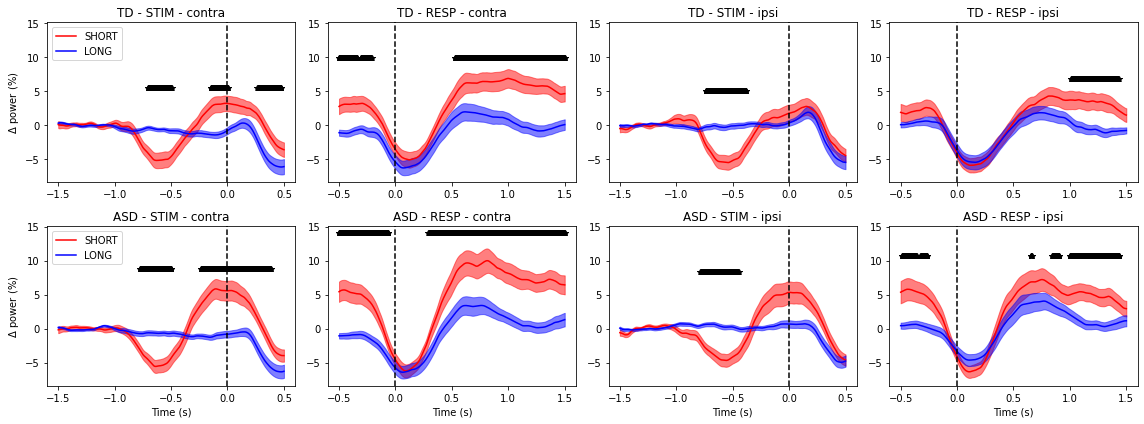

In [16]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'contra', 'TD - STIM - contra', 1),
    ('TD', 'RESP', 'contra', 'TD - RESP - contra', 2),
    ('TD', 'STIM', 'ipsi',  'TD - STIM - ipsi', 3),
    ('TD', 'RESP', 'ipsi',  'TD - RESP - ipsi', 4),
    ('ASD', 'STIM', 'contra', 'ASD - STIM - contra', 5),
    ('ASD', 'RESP', 'contra', 'ASD - RESP - contra', 6),
    ('ASD', 'STIM', 'ipsi',  'ASD - STIM - ipsi', 7),
    ('ASD', 'RESP', 'ipsi',  'ASD - RESP - ipsi', 8)
]

axes = []
for grp, evt, hemi, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    time_bins=[]
    if evt=='STIM':
        time_bins=power_time[t_stim_idx]
    else:
        time_bins=power_time[t_resp_idx]
        
    # Plot SHORT
    m_pow = np.mean(beta_pow_bc[grp][evt]['SHORT'][hemi], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt]['SHORT'][hemi], axis=0) / np.sqrt(beta_pow_bc[grp][evt]['SHORT'][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='SHORT', color=short_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

    # Plot LONG
    m_pow = np.mean(beta_pow_bc[grp][evt]['LONG'][hemi], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt]['LONG'][hemi], axis=0) / np.sqrt(beta_pow_bc[grp][evt]['LONG'][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='LONG', color=long_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

    # Paired t-test
    data = [beta_pow_bc[grp][evt]['SHORT'][hemi], beta_pow_bc[grp][evt]['LONG'][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_bins[p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and hemi == 'contra':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()


stat_fun(H1): min=-2.088861 max=2.278632
Running initial clustering …
Using 228 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.075565 max=3.472204
Running initial clustering …
Using 348 thresholds from 0.00 to 3.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.613459 max=2.059089
Running initial clustering …
Using 362 thresholds from 0.00 to 3.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.792263 max=1.522958
Running initial clustering …
Using 380 thresholds from 0.00 to 3.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.852675 max=0.367803
Running initial clustering …
Using 486 thresholds from 0.00 to 4.85 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

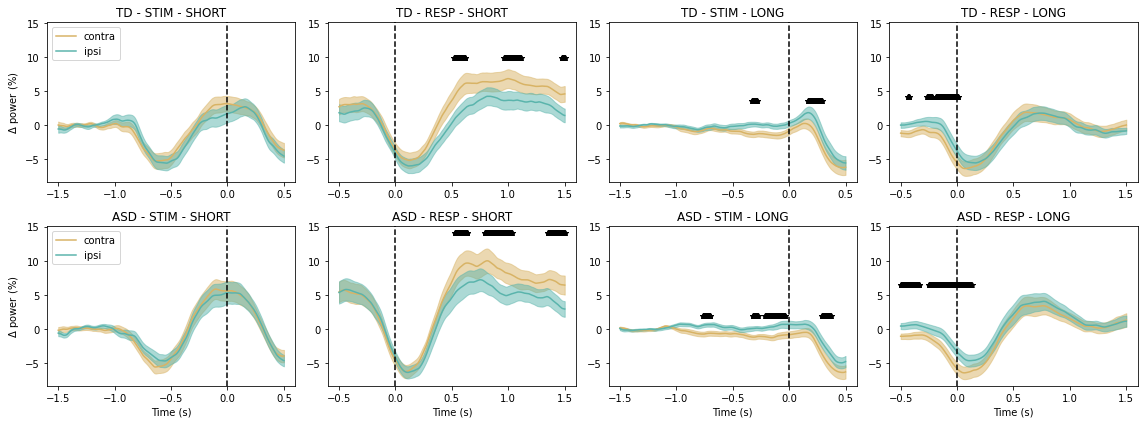

In [17]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'SHORT', 'TD - STIM - SHORT', 1),
    ('TD', 'RESP', 'SHORT', 'TD - RESP - SHORT', 2),
    ('TD', 'STIM', 'LONG',  'TD - STIM - LONG', 3),
    ('TD', 'RESP', 'LONG',  'TD - RESP - LONG', 4),
    ('ASD', 'STIM', 'SHORT', 'ASD - STIM - SHORT', 5),
    ('ASD', 'RESP', 'SHORT', 'ASD - RESP - SHORT', 6),
    ('ASD', 'STIM', 'LONG',  'ASD - STIM - LONG', 7),
    ('ASD', 'RESP', 'LONG',  'ASD - RESP - LONG', 8)
]

axes = []
for grp, evt, dur, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    time_bins=[]
    if evt=='STIM':
        time_bins=power_time[t_stim_idx]
    else:
        time_bins=power_time[t_resp_idx]
        
    # Plot SHORT
    m_pow = np.mean(beta_pow_bc[grp][evt][dur]['contra'], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt][dur]['contra'], axis=0) / np.sqrt(beta_pow_bc[grp][evt][dur]['contra'].shape[0])
    ax.plot(time_bins, m_pow, label='contra', color=contra_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=contra_color)

    # Plot LONG
    m_pow = np.mean(beta_pow_bc[grp][evt][dur]['ipsi'], axis=0)
    se_pow = np.std(beta_pow_bc[grp][evt][dur]['ipsi'], axis=0) / np.sqrt(beta_pow_bc[grp][evt][dur]['ipsi'].shape[0])
    ax.plot(time_bins, m_pow, label='ipsi', color=ipsi_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=ipsi_color)

    # Paired t-test
    data = [beta_pow_bc[grp][evt][dur]['contra'], beta_pow_bc[grp][evt][dur]['ipsi']]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_bins[p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and dur == 'SHORT':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()


# Gamma power

In [18]:
gamma_pow_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

f_idx=(tf_freqs>=60)

for group in ['TD','ASD']:
    for epoch in ['STIM','RESP']:
        for condition in ['SHORT','LONG']:
            for hemi in ['contra','ipsi']:
                for subj_tf in tf_bc[group][epoch][condition][hemi]:
                    gamma_pow_bc[group][epoch][condition][hemi].append(np.mean(subj_tf[f_idx,:],axis=0))
                gamma_pow_bc[group][epoch][condition][hemi]=np.array(gamma_pow_bc[group][epoch][condition][hemi])

stat_fun(H1): min=0.000000 max=2.446232
Running initial clustering …
Using 245 thresholds from 0.00 to 2.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000031 max=1.542737
Running initial clustering …
Using 155 thresholds from 0.00 to 1.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000000 max=1.846449
Running initial clustering …
Using 185 thresholds from 0.00 to 1.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000000 max=1.540626
Running initial clustering …
Using 155 thresholds from 0.00 to 1.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000001 max=0.574784
Running initial clustering …
Using 58 thresholds from 0.00 to 0.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

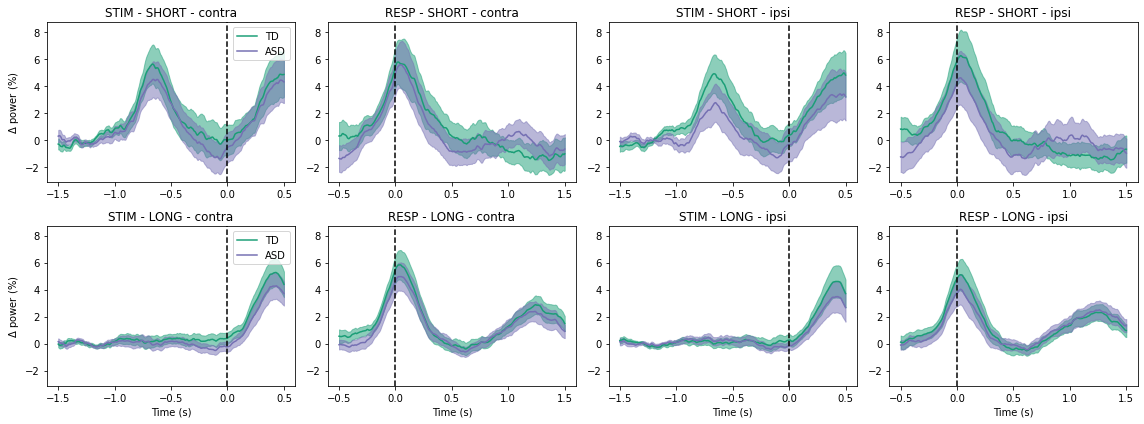

In [19]:
plt.figure(figsize=(16,6))

# Define condition combinations and axes
conditions = [
    ('STIM', 'SHORT', 'contra', plt.subplot(2,4,1), 'STIM - SHORT - contra'),
    ('RESP', 'SHORT', 'contra', plt.subplot(2,4,2), 'RESP - SHORT - contra'),
    ('STIM', 'LONG',  'contra', plt.subplot(2,4,5), 'STIM - LONG - contra'),
    ('RESP', 'LONG',  'contra', plt.subplot(2,4,6), 'RESP - LONG - contra'),
    ('STIM', 'SHORT', 'ipsi',  plt.subplot(2,4,3), 'STIM - SHORT - ipsi'),
    ('RESP', 'SHORT', 'ipsi',  plt.subplot(2,4,4), 'RESP - SHORT - ipsi'),
    ('STIM', 'LONG',  'ipsi',  plt.subplot(2,4,7), 'STIM - LONG - ipsi'),
    ('RESP', 'LONG',  'ipsi',  plt.subplot(2,4,8), 'RESP - LONG - ipsi')
]

threshold_tfce = dict(start=0, step=0.01)
all_axes = []

for evt, dur, hemi, ax, title in conditions:
    time_bins=[]
    if evt=='STIM':
        time_bins=tf_time[t_stim_idx]
    else:
        time_bins=tf_time[t_resp_idx]
    # TD
    m_pow = np.mean(gamma_pow_bc['TD'][evt][dur][hemi], axis=0)
    se_pow = np.std(gamma_pow_bc['TD'][evt][dur][hemi], axis=0) / np.sqrt(gamma_pow_bc['TD'][evt][dur][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='TD', color=td_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=td_color)

    # ASD
    m_pow = np.mean(gamma_pow_bc['ASD'][evt][dur][hemi], axis=0)
    se_pow = np.std(gamma_pow_bc['ASD'][evt][dur][hemi], axis=0) / np.sqrt(gamma_pow_bc['ASD'][evt][dur][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='ASD', color=asd_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=asd_color)

    # Unpaired cluster permutation test
    data = [gamma_pow_bc['ASD'][evt][dur][hemi], gamma_pow_bc['TD'][evt][dur][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0,
        n_jobs=-1
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_bins[p_idx], py, 'k*')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)
    if (hemi == 'contra' and evt == 'STIM' and dur == 'SHORT') or (hemi == 'contra' and evt == 'STIM' and dur == 'LONG'):
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')
    if dur == 'LONG':
        ax.set_xlabel('Time (s)')

    all_axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in all_axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in all_axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()

stat_fun(H1): min=-3.015082 max=3.778217
Running initial clustering …
Using 378 thresholds from 0.00 to 3.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.809183 max=1.164724
Running initial clustering …
Using 281 thresholds from 0.00 to 2.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.349241 max=3.329661
Running initial clustering …
Using 333 thresholds from 0.00 to 3.32 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.310700 max=1.723002
Running initial clustering …
Using 173 thresholds from 0.00 to 1.72 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.256376 max=0.557223
Running initial clustering …
Using 226 thresholds from 0.00 to 2.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

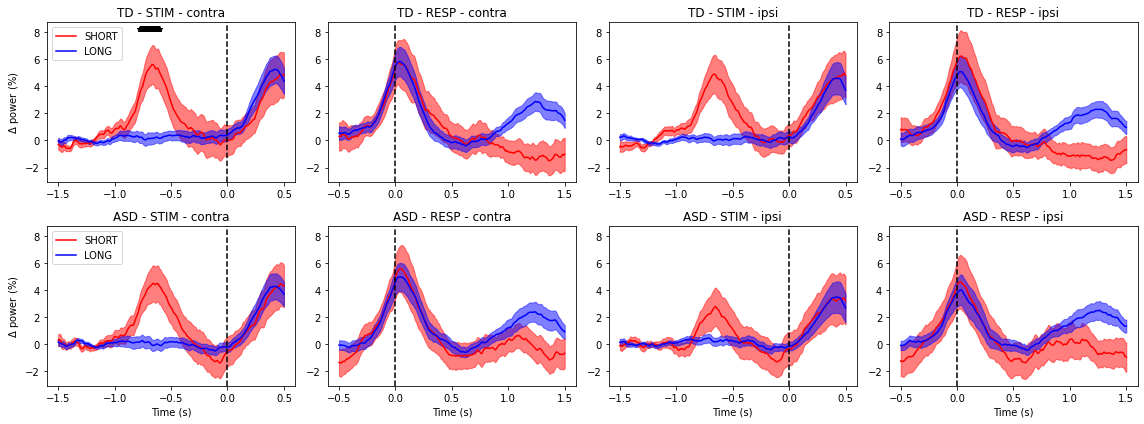

In [20]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'contra', 'TD - STIM - contra', 1),
    ('TD', 'RESP', 'contra', 'TD - RESP - contra', 2),
    ('TD', 'STIM', 'ipsi',  'TD - STIM - ipsi', 3),
    ('TD', 'RESP', 'ipsi',  'TD - RESP - ipsi', 4),
    ('ASD', 'STIM', 'contra', 'ASD - STIM - contra', 5),
    ('ASD', 'RESP', 'contra', 'ASD - RESP - contra', 6),
    ('ASD', 'STIM', 'ipsi',  'ASD - STIM - ipsi', 7),
    ('ASD', 'RESP', 'ipsi',  'ASD - RESP - ipsi', 8)
]

axes = []
for grp, evt, hemi, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    time_bins=[]
    if evt=='STIM':
        time_bins=tf_time[t_stim_idx]
    else:
        time_bins=tf_time[t_resp_idx]
        
    # Plot SHORT
    m_pow = np.mean(gamma_pow_bc[grp][evt]['SHORT'][hemi], axis=0)
    se_pow = np.std(gamma_pow_bc[grp][evt]['SHORT'][hemi], axis=0) / np.sqrt(gamma_pow_bc[grp][evt]['SHORT'][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='SHORT', color=short_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

    # Plot LONG
    m_pow = np.mean(gamma_pow_bc[grp][evt]['LONG'][hemi], axis=0)
    se_pow = np.std(gamma_pow_bc[grp][evt]['LONG'][hemi], axis=0) / np.sqrt(gamma_pow_bc[grp][evt]['LONG'][hemi].shape[0])
    ax.plot(time_bins, m_pow, label='LONG', color=long_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

    # Paired t-test
    data = [gamma_pow_bc[grp][evt]['SHORT'][hemi], gamma_pow_bc[grp][evt]['LONG'][hemi]]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_bins[p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and hemi == 'contra':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()


stat_fun(H1): min=-2.591672 max=1.634847
Running initial clustering …
Using 260 thresholds from 0.00 to 2.59 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.353970 max=1.929320
Running initial clustering …
Using 193 thresholds from 0.00 to 1.92 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.958330 max=1.837304
Running initial clustering …
Using 196 thresholds from 0.00 to 1.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.104063 max=2.446719
Running initial clustering …
Using 245 thresholds from 0.00 to 2.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.502189 max=3.200354
Running initial clustering …
Using 321 thresholds from 0.00 to 3.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

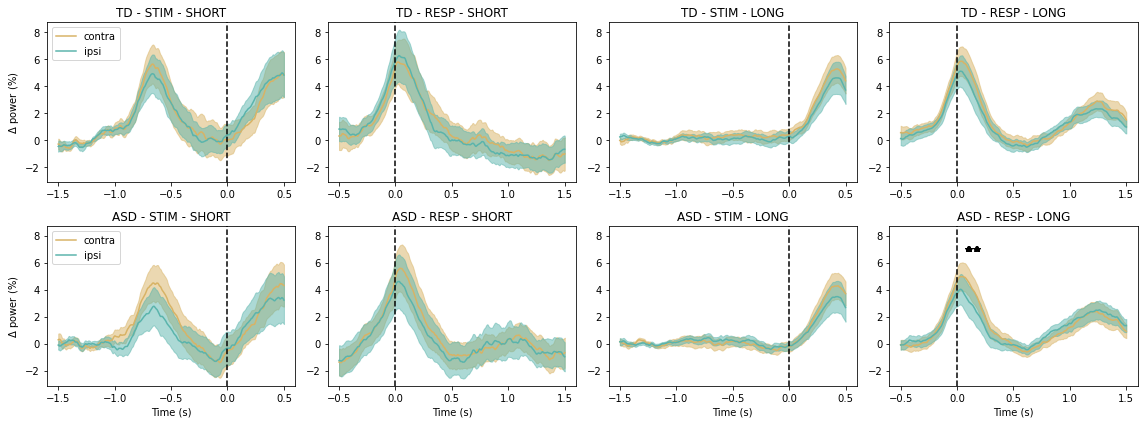

In [21]:
plt.figure(figsize=(16,6))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'SHORT', 'TD - STIM - SHORT', 1),
    ('TD', 'RESP', 'SHORT', 'TD - RESP - SHORT', 2),
    ('TD', 'STIM', 'LONG',  'TD - STIM - LONG', 3),
    ('TD', 'RESP', 'LONG',  'TD - RESP - LONG', 4),
    ('ASD', 'STIM', 'SHORT', 'ASD - STIM - SHORT', 5),
    ('ASD', 'RESP', 'SHORT', 'ASD - RESP - SHORT', 6),
    ('ASD', 'STIM', 'LONG',  'ASD - STIM - LONG', 7),
    ('ASD', 'RESP', 'LONG',  'ASD - RESP - LONG', 8)
]

axes = []
for grp, evt, dur, title, pos in conditions:
    ax = plt.subplot(2, 4, pos)

    time_bins=[]
    if evt=='STIM':
        time_bins=tf_time[t_stim_idx]
    else:
        time_bins=tf_time[t_resp_idx]
        
    # Plot SHORT
    m_pow = np.mean(gamma_pow_bc[grp][evt][dur]['contra'], axis=0)
    se_pow = np.std(gamma_pow_bc[grp][evt][dur]['contra'], axis=0) / np.sqrt(gamma_pow_bc[grp][evt][dur]['contra'].shape[0])
    ax.plot(time_bins, m_pow, label='contra', color=contra_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=contra_color)

    # Plot LONG
    m_pow = np.mean(gamma_pow_bc[grp][evt][dur]['ipsi'], axis=0)
    se_pow = np.std(gamma_pow_bc[grp][evt][dur]['ipsi'], axis=0) / np.sqrt(gamma_pow_bc[grp][evt][dur]['ipsi'].shape[0])
    ax.plot(time_bins, m_pow, label='ipsi', color=ipsi_color)
    ax.fill_between(time_bins, m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=ipsi_color)

    # Paired t-test
    data = [gamma_pow_bc[grp][evt][dur]['contra'], gamma_pow_bc[grp][evt][dur]['ipsi']]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        data,
        stat_fun=paired_t,
        threshold=threshold_tfce,
        n_permutations=1000,
        tail=0
    )

    # Plot significant clusters
    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - 0)
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_bins[p_idx], py, 'k*')

    # Formatting
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(title)

    # Add legend and labels for the first subplot
    if evt == 'STIM' and dur == 'SHORT':
        ax.legend()
        ax.set_ylabel(r'$\Delta$ power (%)')

    # Label bottom row axes
    if grp == 'ASD':
        ax.set_xlabel('Time (s)')

    axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
